In [9]:
import pathlib

import astropy.table
import astropy.units as u
import numpy as np
import matplotlib.pyplot as plt

from astropy.visualization import quantity_support
from scipy.interpolate import interp1d

from mocksipipeline.instrument.configuration import moxsi_built_spectrogram_pinhole

In [10]:
tables = {}
for filename in pathlib.Path('.').glob('*.txt'):
    tab = astropy.table.QTable.read(filename, format='ascii.no_header',)
    tab.remove_column('col3')
    tab.rename_column('col1', 'Energy')
    tab.rename_column('col2', 'Spectra')
    tab = tab[tab['Energy']>0]  # Why are there entries < 0?
    tab['Energy'].unit = 'keV'
    tab['Spectra'].unit = u.ct / u.s / (25*u.mm**2)
    tab['Wavelength'] = tab['Energy'].to('Angstrom', equivalencies=u.spectral())
    tables[filename.stem] = tab

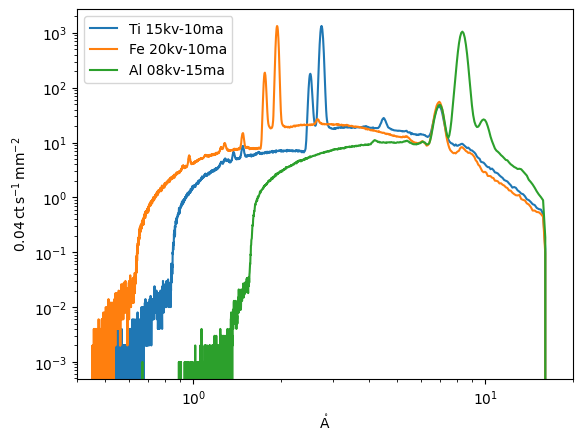

In [11]:
with quantity_support():
    for k,v in tables.items():
        plt.plot(v['Wavelength'], v['Spectra'], label=' '.join(k.split('_')[:2]))
    plt.yscale('log')
    plt.xscale('log')
    plt.xlim(0.4,20)
plt.legend()

In [12]:
spec_order_1 = moxsi_built_spectrogram_pinhole[12]

In [13]:
spec_order_1

MOXSI Detector Channel--spectrogram_pinhole
-----------------------------------
Spectral order: 1
Filter: Al+Al2O3, $150 \; \mathrm{nm}$
Detector dimensions: (1504, 2000)
Wavelength range: [ 0.         84.43076923] Angstrom
Spectral plate scale: 0.07179487179487179 Angstrom / pix
Spatial plate scale: [6.94160406 6.94160406] arcsec / pix
Reference pixel: [1000.  752.    0.] pix
aperture: Circular Aperture
-------------------------
name: circular_44
diameter: 44.0 micron
area: 1.5205308443374597e-05 cm2


(1e-08, 1e-05)

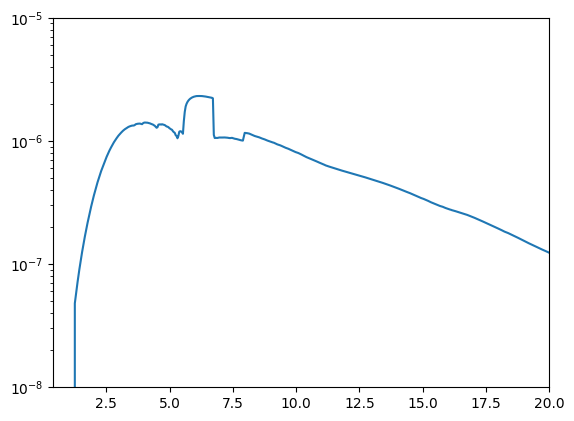

In [41]:
plt.plot(spec_order_1.wavelength, spec_order_1.effective_area)
plt.yscale('log')
#plt.xscale('log')
plt.xlim(0.4,20)
plt.ylim(1e-8, 1e-5)

In [36]:
moxsi_built_spectrogram_pinhole[12].spectral_order

np.int64(1)

/Users/wtbarnes/miniforge3/envs/moxsi-science/lib/python3.13/site-packages/astropy/units/equivalencies.py:162: RuntimeWarning: divide by zero encountered in divide
  (si.m, si.J, lambda x: hc / x),
/Users/wtbarnes/miniforge3/envs/moxsi-science/lib/python3.13/site-packages/astropy/units/equivalencies.py:162: RuntimeWarning: divide by zero encountered in divide
  (si.m, si.J, lambda x: hc / x),
/Users/wtbarnes/miniforge3/envs/moxsi-science/lib/python3.13/site-packages/astropy/units/equivalencies.py:162: RuntimeWarning: divide by zero encountered in divide
  (si.m, si.J, lambda x: hc / x),
/Users/wtbarnes/miniforge3/envs/moxsi-science/lib/python3.13/site-packages/astropy/units/equivalencies.py:162: RuntimeWarning: divide by zero encountered in divide
  (si.m, si.J, lambda x: hc / x),
/Users/wtbarnes/miniforge3/envs/moxsi-science/lib/python3.13/site-packages/astropy/units/equivalencies.py:162: RuntimeWarning: divide by zero encountered in divide
  (si.m, si.J, lambda x: hc / x),
/Users/wtb

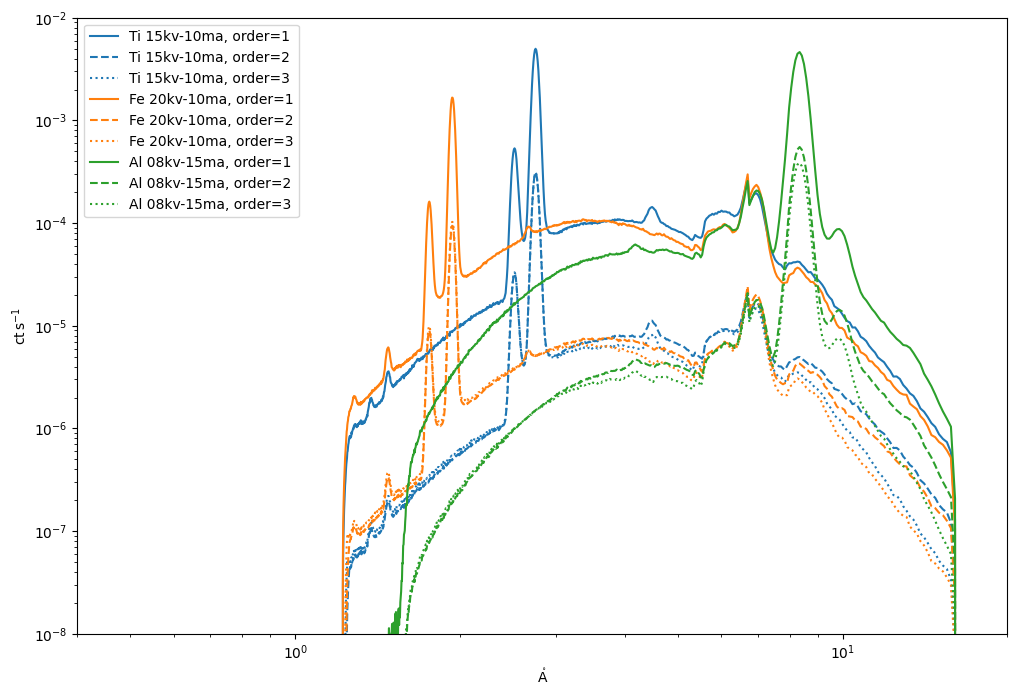

In [37]:
plt.figure(figsize=(12,8))
with quantity_support():
    for j,(k,v) in enumerate(tables.items()):
        ls = ['-', '--', ':']
        for i in range(12,15):
            ea = interp1d(moxsi_built_spectrogram_pinhole[i].wavelength.to_value('AA'), moxsi_built_spectrogram_pinhole[i].effective_area.to('cm2'), fill_value=0, bounds_error=False)(v['Wavelength'].to_value('AA'))*u.cm**2
            signal = (v['Spectra']*ea).to('ct s-1')
            plt.plot(v['Wavelength'],
                     signal,
                     label=' '.join(k.split('_')[:2])+f', order={moxsi_built_spectrogram_pinhole[i].spectral_order}',
                     ls=ls[i-12],
                     color=f'C{j}')
    plt.yscale('log')
    plt.xscale('log')
    plt.xlim(0.4,20)
    plt.ylim(1e-8, 1e-2)
plt.legend()

In [20]:
v['Wavelength']

<Quantity [2.05756263e+03, 6.36664342e+02, 3.76596658e+02, ...,
           4.51608660e-01, 4.51387549e-01, 4.51166654e-01] Angstrom>

In [21]:
v['Wavelength'].min()

<Quantity 0.45116665 Angstrom>

In [22]:
signal[-1]

<Quantity 0. ct / s>

In [ ]:
spec_order_1

(0.4, 20.0)

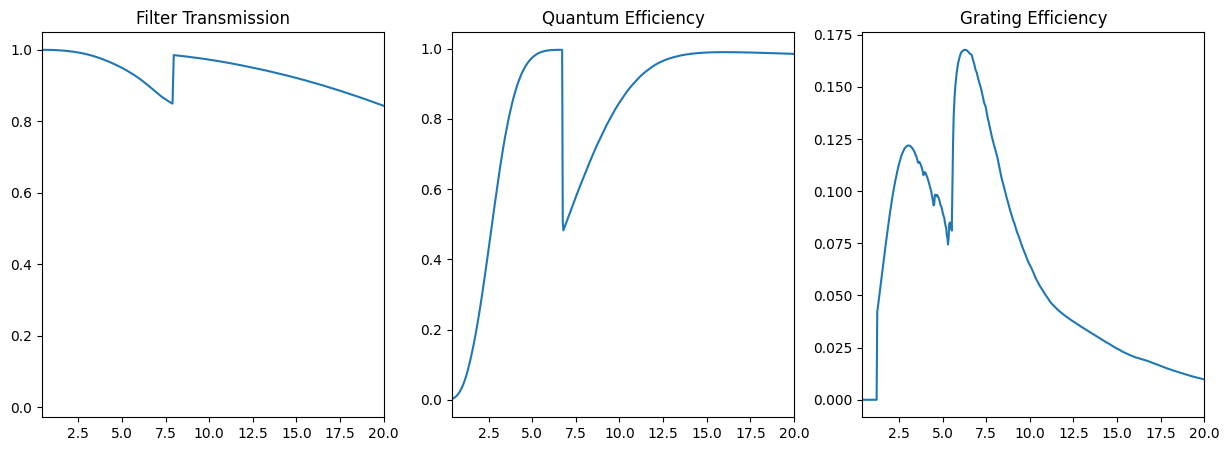

In [54]:
fig,axes=plt.subplots(1,3,figsize=(15,5),sharex=True)
axes[0].plot(spec_order_1.wavelength, spec_order_1.filter_transmission)
axes[0].set_title('Filter Transmission')
axes[1].plot(spec_order_1.wavelength, spec_order_1.quantum_efficiency)
axes[1].set_title('Quantum Efficiency')
axes[2].plot(spec_order_1.wavelength, spec_order_1.grating_efficiency)
axes[2].set_title('Grating Efficiency')
axes[0].set_xlim(0.4,20)

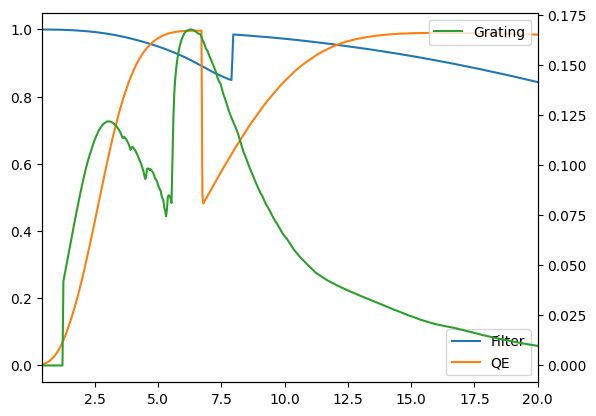

In [57]:
fig = plt.figure()
ax = fig.add_subplot()
ax.plot(spec_order_1.wavelength, spec_order_1.filter_transmission, label='Filter')
ax.plot(spec_order_1.wavelength, spec_order_1.quantum_efficiency, label='QE')
ax2 = ax.twinx()
ax2.plot(spec_order_1.wavelength, spec_order_1.grating_efficiency, label='Grating', color='C2')
ax.set_xlim(0.4,20)
ax.legend()
ax2.legend()

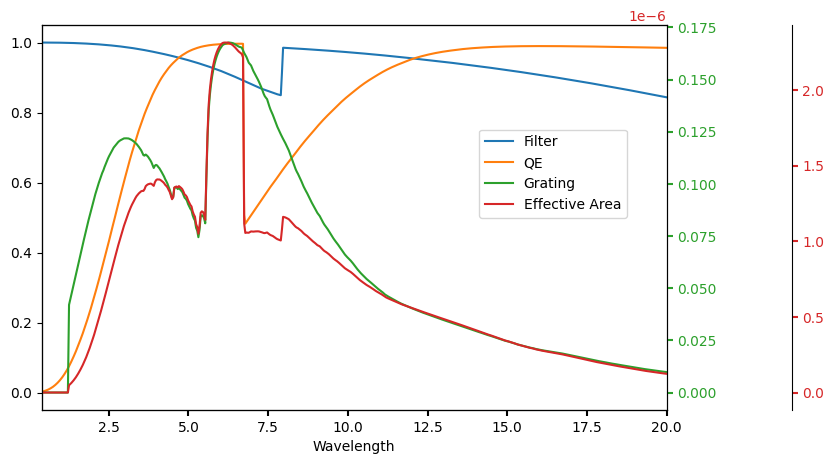

In [63]:
import matplotlib.pyplot as plt


fig, ax = plt.subplots(figsize=(10,5))
fig.subplots_adjust(right=0.75)

twin1 = ax.twinx()
twin2 = ax.twinx()

# Offset the right spine of twin2.  The ticks and label have already been
# placed on the right by twinx above.
twin2.spines.right.set_position(("axes", 1.2))

p1, = ax.plot(spec_order_1.wavelength, spec_order_1.filter_transmission, label='Filter', color='C0')
p2, = ax.plot(spec_order_1.wavelength, spec_order_1.quantum_efficiency, label='QE', color='C1')
p3, = twin1.plot(spec_order_1.wavelength, spec_order_1.grating_efficiency, label='Grating', color='C2')
p4, = twin2.plot(spec_order_1.wavelength, spec_order_1.effective_area, label="Effective Area", color='C3')

ax.set_xlim(0.4, 20)

ax.set_xlabel("Wavelength")

ax.yaxis.label.set_color('k')
twin1.yaxis.label.set_color(p3.get_color())
twin2.yaxis.label.set_color(p4.get_color())

tkw = dict(size=4, width=1.5)
twin1.tick_params(axis='y', colors=p3.get_color(), **tkw)
twin2.tick_params(axis='y', colors=p4.get_color(), **tkw)
ax.tick_params(axis='x', **tkw)

ax.legend(handles=[p1, p2, p3, p4], loc=(0.7,0.5))

plt.show()